# PaySim Fraud EDA Notebook


## Imports
Load the libraries used for preprocessing, analysis, and PCA.

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt

## Load Dataset
Read the PaySim dataset into a DataFrame and preview the first rows.

In [2]:
DATA_CANDIDATES = [
    os.environ.get("PAYSIM_DATA_PATH"),
    "paysim dataset.csv",
    "paysim_dataset.csv",
    "paysim.csv",
    "/content/drive/MyDrive/paysim/paysim dataset.csv",
]

DATA_PATH = next((p for p in DATA_CANDIDATES if p and os.path.exists(p)), None)
if DATA_PATH is None:
    raise FileNotFoundError(
        "Could not find the PaySim dataset. Set PAYSIM_DATA_PATH or place the CSV next to this notebook."
    )

df_raw = pd.read_csv(DATA_PATH)

print(f"Loaded: {DATA_PATH}")
df_raw.head()

Loaded: paysim.csv


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


## Schema Structure
Inspect the dataset structure, summary statistics, and fraud class distribution.

In [3]:
print("Shape:", df_raw.shape)
df_raw.info()
df_raw.describe(include="all")
df_raw["isFraud"].value_counts()
df_raw["isFraud"].value_counts(normalize=True) * 100

Shape: (6362620, 11)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


isFraud
0    99.870918
1     0.129082
Name: proportion, dtype: float64

## Clean Data
Check for duplicates and missing values, then remove duplicate records.

In [4]:
df = df_raw.copy()

print("Duplicates before:", df.duplicated().sum())
df = df.drop_duplicates()
print("Duplicates after:", df.duplicated().sum())

df.isnull().sum()

Duplicates before: 0


Duplicates after: 0


step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

## Validate Balance Logic
Compare expected sender and receiver balances against recorded post-transaction balances.

In [5]:
balance_check = pd.DataFrame({
    "amount": df["amount"],
    "oldbalanceOrg": df["oldbalanceOrg"],
    "newbalanceOrig": df["newbalanceOrig"],
    "sender_balance_error": (df["oldbalanceOrg"] - df["amount"]) - df["newbalanceOrig"],
    "oldbalanceDest": df["oldbalanceDest"],
    "newbalanceDest": df["newbalanceDest"],
    "receiver_balance_error": (df["oldbalanceDest"] + df["amount"]) - df["newbalanceDest"],
    "isFraud": df["isFraud"],
})

balance_check.head()

,amount,oldbalanceOrg,newbalanceOrig,sender_balance_error,oldbalanceDest,newbalanceDest,receiver_balance_error,isFraud
0,9839.64,170136.0,160296.36,0.0,0.0,0.0,9839.64,0
1,1864.28,21249.0,19384.72,0.0,0.0,0.0,1864.28,0
2,181.00,181.0,0.00,0.0,0.0,0.0,181.00,1
3,181.00,181.0,0.00,0.0,21182.0,0.0,21363.00,1
4,11668.14,41554.0,29885.86,0.0,0.0,0.0,11668.14,0


## Engineer Features
Create balance deltas, mismatch features, log transforms, and customer time gaps.

In [6]:
df = df.sort_values(["nameOrig", "step"]).reset_index(drop=True)
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,249,CASH_OUT,244486.46,C1000000639,8946.00,0.00,C785826240,526950.37,771436.84,0,0
1,217,PAYMENT,3170.28,C1000001337,58089.00,54918.72,M216466820,0.00,0.00,0,0
2,46,PAYMENT,8424.74,C1000001725,783.00,0.00,M1974356374,0.00,0.00,0,0
3,231,CASH_IN,261877.19,C1000002591,7596.00,269473.19,C503690069,1126627.70,864750.51,0,0
4,167,CASH_IN,20528.65,C1000003372,2302074.12,2322602.77,C1840417793,82696.17,62167.52,0,0


## Create Aggregates
Build grouped summaries for fraud rate, transaction volume, time trends, and amount bands.

In [7]:
fraud_rate_by_type = df.groupby("type")["isFraud"].mean().sort_values(ascending=False)
volume_by_type = df["type"].value_counts()

fraud_by_amount_quantile = df.groupby(
    pd.qcut(df["amount"].rank(method="first"), q=20, labels=False)
)["isFraud"].mean()

## Sampling for Heavy Plots
Create a stratified sample so dense visualizations remain readable and efficient.

In [8]:
print("Sampling is not needed for the retained visualizations in this notebook.")

Sampling is not needed for the retained visualizations in this notebook.


## Save Figures Folder
Create the output folder used to save the selected charts.

In [9]:
OUTDIR = os.environ.get("PAYSIM_OUTDIR", "paysim_selected_figures")
os.makedirs(OUTDIR, exist_ok=True)
print(f"Figures will be saved to: {OUTDIR}")

Figures will be saved to: paysim_selected_figures


## Fraud Is Extremely Rare
Visualize the strong class imbalance between legitimate and fraudulent transactions.

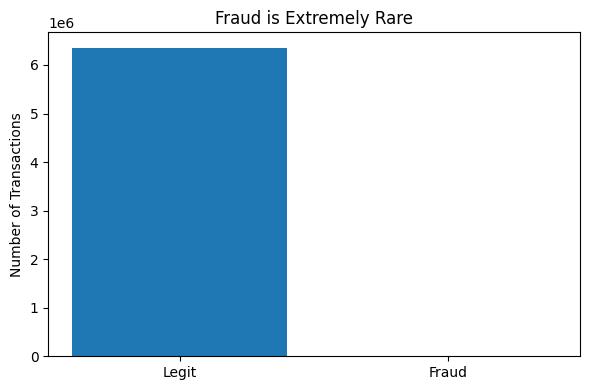

In [10]:
counts = df["isFraud"].value_counts().sort_index()

plt.figure(figsize=(6,4))
plt.bar(["Legit", "Fraud"], [counts.get(0, 0), counts.get(1, 0)])
plt.title("Fraud is Extremely Rare")
plt.ylabel("Number of Transactions")
plt.tight_layout()
plt.savefig(f"{OUTDIR}/fraud_is_extremely_rare.png", dpi=200)
plt.show()

## Volume Differs by Type
Show how transaction counts vary across transaction types.

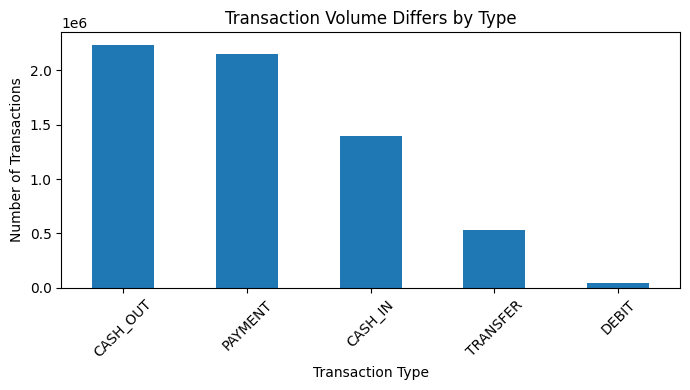

In [11]:
plt.figure(figsize=(7,4))
volume_by_type.plot(kind="bar")
plt.title("Transaction Volume Differs by Type")
plt.xlabel("Transaction Type")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(f"{OUTDIR}/transaction_volume_differs_by_type.png", dpi=200)
plt.show()

## Fraud Does Not Match Volume Patterns
Compare fraud risk by transaction type rather than just raw transaction volume.

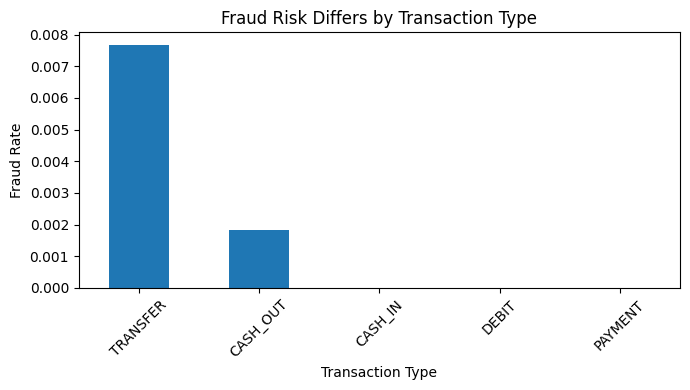

In [12]:
plt.figure(figsize=(7,4))
fraud_rate_by_type.plot(kind="bar")
plt.title("Fraud Risk Differs by Transaction Type")
plt.xlabel("Transaction Type")
plt.ylabel("Fraud Rate")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(f"{OUTDIR}/fraud_risk_differs_by_transaction_type.png", dpi=200)
plt.show()

## Fraud Risk Increases with Amount
Plot fraud rate across transaction amount quantiles.

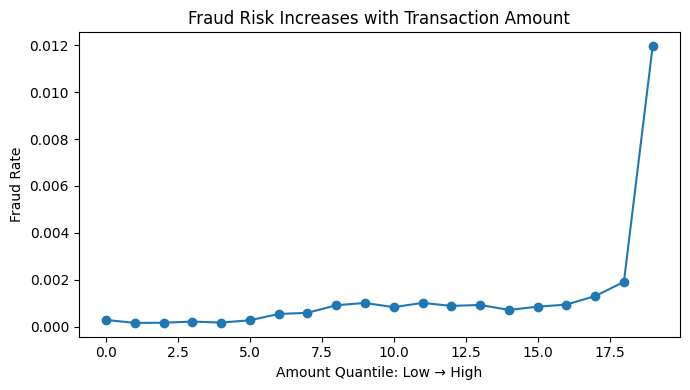

In [13]:
plt.figure(figsize=(7,4))
plt.plot(fraud_by_amount_quantile.index, fraud_by_amount_quantile.values, marker="o")
plt.title("Fraud Risk Increases with Transaction Amount")
plt.xlabel("Amount Quantile: Low → High")
plt.ylabel("Fraud Rate")
plt.tight_layout()
plt.savefig(f"{OUTDIR}/fraud_risk_increases_with_transaction_amount.png", dpi=200)
plt.show()

## Fraud Has Transaction-Type Sequence Patterns
Examine how fraudulent transactions transition from one type to the next.

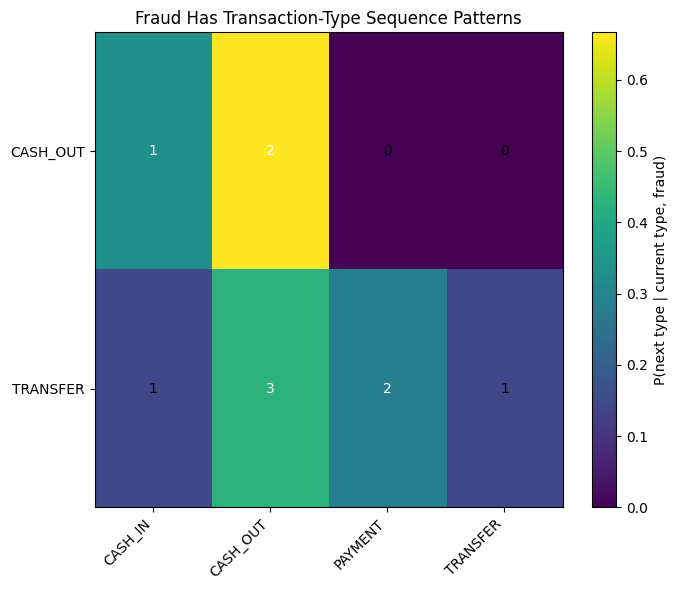

In [14]:
df_trans = df.sort_values(["nameOrig", "step"]).copy()
df_trans["next_type"] = df_trans.groupby("nameOrig")["type"].shift(-1)
df_trans = df_trans.dropna(subset=["next_type"])

fraud_trans = df_trans[df_trans["isFraud"] == 1]

fraud_counts = pd.crosstab(fraud_trans["type"], fraud_trans["next_type"])
fraud_matrix = pd.crosstab(
    fraud_trans["type"],
    fraud_trans["next_type"],
    normalize="index"
)

row_labels = fraud_matrix.index.tolist()
col_labels = fraud_matrix.columns.tolist()

plt.figure(figsize=(7, 6))
plt.imshow(fraud_matrix.values, aspect="auto")
plt.title("Fraud Has Transaction-Type Sequence Patterns")
plt.xticks(range(len(col_labels)), col_labels, rotation=45, ha="right")
plt.yticks(range(len(row_labels)), row_labels)

for i, row in enumerate(row_labels):
    for j, col in enumerate(col_labels):
        pct = fraud_matrix.loc[row, col]
        count = fraud_counts.loc[row, col]
        text_color = "white" if pct >= 0.25 else "black"
        plt.text(j, i, f"{count}", ha="center", va="center", color=text_color, fontsize=10)

plt.colorbar(label="P(next type | current type, fraud)")
plt.tight_layout()
plt.savefig(f"{OUTDIR}/fraud_has_transaction_type_sequence_patterns.png", dpi=200)
plt.show()